---
## <center> LIVRABLE MODÉLISATION 
---
ÉQUIPE :
- LECLERCQ SIMON 
- GUZMAN RUBENS 
- NEDELEC ELOISE

---

RAPPEL DU CONTEXTE :

L’Agence de l’Environnement et de la Maîtrise de l’Énergie (ADEME) a lancé un appel d’offres visant à favoriser le développement de solutions de transport plus économes en énergie et respectueuses de l’environnement.

Le projet consiste à déterminer un itinéraire optimal entre plusieurs villes, en prenant en compte la durée du trajet ainsi que le type de marchandises transportées.

La solution proposée devra être capable de traiter de très grandes instances (impliquant plusieurs milliers de villes) et devra inclure une analyse statistique détaillée du comportement expérimental de l’algorithme mis en œuvre.

--- 

CONTRAINTES CHOISIES : 

Points de collecte : Mutli-dépôts + spécificité par objet 
-> Nous avons choisi cette deuxième contrainte car, dans la réalité, les entreprises disposent souvent de plusieurs entrepôts, et les produits doivent être collectés à différents endroits avant d’être livrés au client final. Cette contrainte modélise très bien une chaîne logistique complexe et réaliste, dans laquelle chaque objet possède son propre parcours de collecte avant sa livraison.


---

# Recherche opérationnelle

## 1. Définition du problème

Nous cherchons à minimiser le coût total des tournées de camions pour desservir un ensemble de clients à partir de dépôts, en respectant les contraintes suivantes :

Chaque client a une demande spécifique, qui peut nécessiter plusieurs types d’objets provenant de dépôts différents.

Chaque camion part d’un dépôt, collecte les objets nécessaires, et livre aux clients.

Chaque ville est reliée par un réseau de routes avec des distances connues.

Les camions doivent retourner à leur dépôt initial après avoir effectué leurs livraisons.

On peut assimiler le problème à une variante du problème de tournée de véhicules (Vehicle Routing Problem, VRP) avec pickups et deliveries (VRPPD).



## 2. Paramètres et variables

### Paramètres connus
- `C = {c_1, c_2, ..., c_n}` : ensemble des clients  
- `D = {d_1, d_2, ..., d_m}` : ensemble des dépôts  
- `V = C ∪ D` : ensemble des villes  
- `dist(u,v)` : distance minimale entre deux villes `u` et `v`  
- `k` : nombre de camion
- `demande_i` : objets demandés par le client `i`  

### Variables décisionnelles
- `x_ijk = 1` si le camion `k` va directement de la ville `i` à la ville `j`, 0 sinon  
- `route_k` : séquence ordonnée des villes parcourues par le camion `k`  

### Objectif
Minimiser la distance totale parcourue par tous les camions :

$$
\min \sum_{k=1}^{NB\_TRUCKS} \sum_{i,j \in V} dist(i,j) \cdot x_{ijk}
$$


---

## 3. Contraintes

1. **Livraison de tous les clients**  
   Chaque client doit être desservi exactement une fois :  
   $$
   \sum_{k=1}^{NB\_TRUCKS} \sum_{i \in V} x_{ijk} = 1, \quad \forall j \in C
   $$ 

2. **Démarrage et retour aux dépôts**  
   - Chaque camion commence à son dépôt assigné.  
   - Chaque camion revient à son dépôt après avoir servi ses clients.  

3. **Pickup avant livraison**  
   - Les objets doivent être collectés dans les dépôts avant d’être livrés aux clients.  
   - Pour chaque client `i` et chaque objet `o ∈ demande_i`, le camion doit visiter un dépôt `d` où `o` est disponible **avant de visiter le client**.  

4. **Intégrité des tournées**  
   - Aucune ville ne doit être visitée plusieurs fois par le même camion (sauf éventuellement le dépôt final).


---


## 4. Modélisation

Le problème peut être modélisé comme un **VRPPD multi-dépôt** (Vehicle Routing Problem with Pickup and Delivery) :

- **Graphes** : \(G=(V,E)\) avec des distances pondérées entre les villes et dépôts.  
- **Séquences ordonnées** : chaque camion suit un ordre de visites (dépôt → pickups → clients).  
- **Objectif** : minimiser la distance totale parcourue tout en respectant les contraintes de pickups et deliveries.  

### Méthodes de résolution

on a testé différentes meta heuristiques pour comparer les resultats et choisir la meilleure, on voulait comparer des Mh de types différents, une inspirée de la nature (algo génétique) et une basées sur la recherche locale (tabou).


**Heuristiques :**
- **Floyd Warshall**
- **Algorithmes génétiques** (comme le script développé).  
- **Recherche tabou**, **recherche locale**, **recuit simulé**.  

---

## 5. Indicateurs de performance

Pour évaluer la qualité des solutions, plusieurs indicateurs sont utilisés :

- **Distance totale parcourue** par tous les camions.  
- **Temps de calcul** pour générer les tournées.  
- **Respect des contraintes** de pickups et livraisons (tous les objets sont collectés et livrés correctement).  

---

## 6. Approche pratique

1. **Prétraitement** :  
   - Générer les distances minimales entre toutes les villes via **Floyd-Warshall**.  
   - Associer chaque client à ses dépôts possibles.

2. **Répartition des clients** :  
   - Assigner les clients aux camions selon une répartition simple ou une heuristique.

3. **Optimisation des séquences** :  
   - Pour chaque camion, optimiser l’ordre des visites avec un **algorithme génétique** ou **tabou**.

4. **Calcul de la distance réelle** :  
   - Déployer l’ordre des key-nodes en routes complètes en incluant les segments intermédiaires.  
   - Calculer la distance totale réelle parcourue par le camion.



---

# Plan Méthodologique pour l'Optimisation de Tournées de Livraison

*Ce plan vise à déterminer la stratégie de livraison la plus efficace en comparant une solution à véhicule unique à une solution multi-véhicules, en tenant compte des contraintes opérationnelles et des conditions de trafic.*

---

## Phase 1 : Modélisation et Paramétrage du Réseau Logistique

*L'objectif de cette phase est de digitaliser l'environnement opérationnel et de quantifier les variables.*

1.  **Définition du Graphe Réseau :**
    *   Identifier tous les points géographiques pertinents (dépôts, clients, carrefours).
    *   Modéliser ces points comme des **nœuds** et les routes possibles comme des **arêtes** pour former un graphe.

2.  **Identification des Acteurs et Objectifs :**
    *   Spécifier l'emplacement du ou des **dépôt(s)** de départ/retour.
    *   Lister l'ensemble des **clients** à livrer.
    *   Définir la **flotte de véhicules** disponible (nombre de camions).

3.  **Évaluation des Coûts de Trajet :**
    *   Attribuer un **poids** (coût) à chaque arête. Ce coût doit idéalement représenter le **temps de trajet moyen** incluant l'impact du trafic.

---

## Phase 2 : Calcul de la Matrice des Coûts Optimaux

*Cette phase de pré-calcul est cruciale pour simplifier et accélérer les optimisations futures.*

4.  **Construction de la Matrice des Trajets les Plus Courts :**
    *   Utiliser un algorithme comme **Dijkstra** pour calculer le chemin le plus court entre chaque paire de nœuds d'intérêt (dépôt et clients).
    *   Le résultat est une **matrice de coûts** qui sert de table de consultation rapide.
      *   *Exemple : `Coût(Dépôt, Client A) = 15 min`.*

---

## Phase 3 : Optimisation et Sélection de la Stratégie Multi-Véhicules

*Cette phase vise à élaborer la stratégie optimale de tournées lorsque plusieurs véhicules sont mobilisés simultanément. Le problème est ici assimilé à un **Vehicle Routing Problem (VRP)**, extension naturelle du problème du voyageur de commerce, mais à dimension collective.*

### Objectif Général

L’enjeu principal consiste à **répartir l’ensemble des clients entre les différents véhicules disponibles**, puis à **déterminer pour chacun d’eux l’ordre de visite optimal**, de manière à **minimiser le coût global des déplacements**.  
Cette démarche doit par ailleurs respecter les contraintes inhérentes à chaque tournée (type de chargement, plages horaires, etc.).

### Approche Méthodologique

Face à la complexité combinatoire du VRP, une résolution exacte s’avère rapidement inenvisageable. Nous recourrons donc à des **métaheuristiques**, méthodes d’optimisation approchée permettant d’explorer intelligemment un vaste espace de solutions.  
Parmi celles-ci, l’on peut envisager l’utilisation du **recuit simulé**, de la **recherche tabou** ou encore des **algorithmes génétiques**, réputés pour leur capacité à converger vers des solutions de grande qualité sans garantir pour autant l’optimalité absolue.

### Étapes Principales

1. **Partitionnement des clients** : regroupement des points de livraison selon des critères géographiques ou logistiques afin de constituer des ensembles cohérents attribués à chaque véhicule.  
2. **Optimisation des tournées individuelles** : détermination, pour chaque groupe de clients, de l’ordre de visite minimisant le coût du parcours à l’aide d’une métaheuristique adaptée.  
3. **Évaluation du coût global** : agrégation des coûts individuels de chaque tournée afin d’obtenir la performance totale du système logistique.  
4. **Sélection de la meilleure configuration** : identification de la répartition et des itinéraires produisant le coût global minimal tout en assurant un équilibre raisonnable des charges de travail entre les véhicules.

---

## Phase 4 : Étude Expérimentale des Métaheuristiques (Tabou vs Génétique)

### 1. Contexte de l'Expérimentation

L'étude expérimentale a été réalisée sur des instances de **6 à 100 villes**.

La génération des villes inclut entre 0 et 3 clients par ville, représentant une moyenne de 2 clients par ville. L'échantillon d'étude varie donc de **12 à 200 clients** en moyenne.

Les calculs d'instances ont été réalisés, et les résultats stockés pour optimiser le temps d'exécution de cette étude. Les données notées pour chaque algorithme sont : `[minimum, moyenne, maximum]` pour 6, 10, 20, 30, 50 et 100 villes.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

### 2. Comparaison avec un Seul Camion ($k=1$) :

#### A. Qualité de la Solution (Meilleur Trajet, km) :

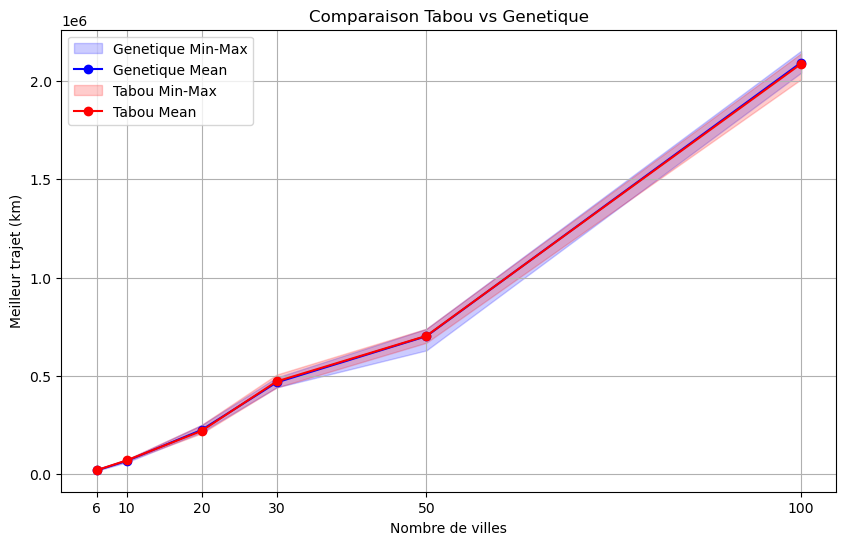

In [12]:
algo_genetics = np.array([
    [16736, 18735, 20318],
    [59351, 66779, 72655],
    [213169, 224150, 249740],
    [440590, 465936, 490813],
    [629359, 701520, 739108],
    [2042670, 2094267, 2154493]
])

algo_taboo = np.array([
    [18188, 19279, 20318],
    [65586, 69318, 74293],
    [206782, 219539, 249740],
    [439942, 470935, 505820],
    [668222, 703091, 739672],
    [2009371, 2088105, 2141314]
])

x = [6, 10, 20, 30, 50, 100]

offset = 0

plt.figure(figsize=(10,6))

plt.fill_between(np.array(x) - offset, algo_genetics[:,0], algo_genetics[:,2], color='blue', alpha=0.2, label='Genetique Min-Max')
plt.plot(np.array(x) - offset, algo_genetics[:,1], 'o-', color='blue', label='Genetique Mean')

plt.fill_between(np.array(x) + offset, algo_taboo[:,0], algo_taboo[:,2], color='red', alpha=0.2, label='Tabou Min-Max')
plt.plot(np.array(x) + offset, algo_taboo[:,1], 'o-', color='red', label='Tabou Mean')

plt.xlabel("Nombre de villes")
plt.ylabel("Meilleur trajet (km)")
plt.title("Comparaison Tabou vs Genetique")
plt.xticks(x)
plt.grid(True)
plt.legend()
plt.show()

| Élément | Algorithme Génétique (Bleu) | Algorithme Tabou (Rouge) | Interprétation |
| :--- | :--- | :--- | :--- |
| **Courbe Moyenne** | `Genetique Mean` | `Tabou Mean` | Les deux courbes de moyenne sont **pratiquement confondues**. Elles affichent une croissance similaire, suggérant que les deux algorithmes trouvent des solutions de coût quasi-identiques à cette échelle. |
| **Plage Min-Max** | `Genetique Min-Max` | `Tabou Min-Max` | Les deux zones de variabilité se **chevauchent largement**. L'écart entre le minimum et le maximum est faible par rapport à la valeur totale du trajet, indiquant une **bonne stabilité** pour les deux méthodes. |

####  Conclusion de l'Analyse (Qualité de Solution à Grande Échelle)

Pour des instances complexes (jusqu'à 100 villes), il y a une **forte corrélation** et une **quasi-égalité** dans la qualité de la solution (Meilleur Trajet) trouvée par l'Algorithme Tabou et l'Algorithme Génétique. L'algorithme génétique présente une solution moyenne légèrement supérieure (coût plus faible), mais la différence est minime.

#### B. Temps d'Exécution (s) :

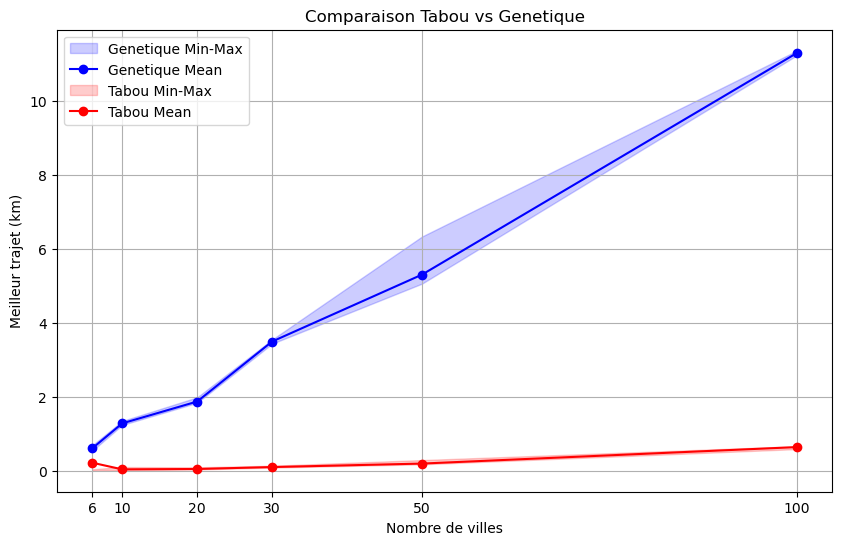

In [ ]:
algo_genetics = np.array([
    [0.553, 0.618, 0.7],
    [1.251, 1.293, 1.357],
    [1.849, 1.883, 1.996],
    [3.445, 3.503, 3.556],
    [5.067, 5.31, 6.339],
    [11.23, 11.293, 11.356]
])

algo_taboo = np.array([
    [0.014, 0.23, 0.054],
    [0.031, 0.051, 0.114],
    [0.048, 0.061, 0.106],
    [0.098, 0.113, 0.149],
    [0.187, 0.207, 0.302],
    [0.598, 0.652, 0.675]
])

x = [6, 10, 20, 30, 50, 100]

offset = 0

plt.figure(figsize=(10,6))

plt.fill_between(np.array(x) - offset, algo_genetics[:,0], algo_genetics[:,2], color='blue', alpha=0.2, label='Genetique Min-Max')
plt.plot(np.array(x) - offset, algo_genetics[:,1], 'o-', color='blue', label='Genetique Mean')

plt.fill_between(np.array(x) + offset, algo_taboo[:,0], algo_taboo[:,2], color='red', alpha=0.2, label='Tabou Min-Max')
plt.plot(np.array(x) + offset, algo_taboo[:,1], 'o-', color='red', label='Tabou Mean')

plt.xlabel("Nombre de villes")
plt.ylabel("Temps d'execution (s)")
plt.title("Comparaison Tabou vs Genetique")
plt.xticks(x)
plt.grid(True)
plt.legend()
plt.show()

| Algorithme | Observation (Temps d'Exécution) |
| :--- | :--- |
| **Tabou** (Rouge) | Le temps d'exécution moyen (`Tabou Mean`) reste **très faible** (inférieur à 0.652 s) même pour 100 villes. |
| **Génétique** (Bleu) | Le temps d'exécution moyen (`Genetique Mean`) **augmente considérablement** avec le nombre de villes, atteignant environ **11,356 secondes** pour 100 villes. La plage Min-Max est très large. |
| **Conclusion** | Le temps d'exécution de l'Algorithme **Génétique croît fortement**, contrastant avec le temps quasi constant de l'Algorithme Tabou. |

### 3. Comparaison avec la Variation du Nombre de Camions (k ≈1 pour 6 clients)

Cette section analyse l'impact de la variation du nombre de camions ($k$) sur l'efficacité des algorithmes.

#### A. Qualité de la Solution (Meilleur Trajet, km)

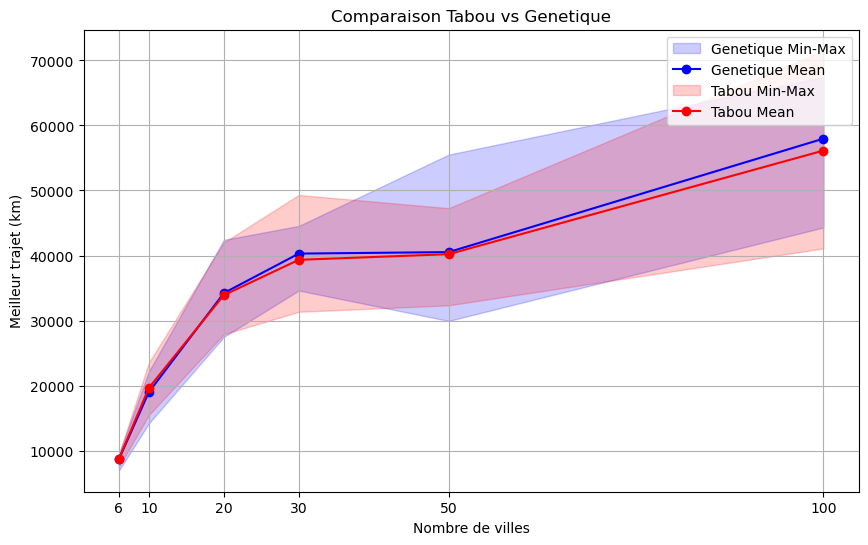

In [11]:
algo_genetics = np.array([
    [6922.0,  8690.90,  9434.0],
    [14194.0, 19007.00, 22184.0],
    [27484.0, 34226.65, 42416.0],
    [34623.0, 40300.40, 44551.0],
    [29949.0, 40529.80, 55519.0],
    [44314.0, 57967.95, 67431.0]
])

algo_taboo = np.array([
    [7534.0,  8707.80,  9434.0],
    [15480.0, 19659.65, 23546.0],
    [27898.0, 33911.75, 42017.0],
    [31352.0, 39343.25, 49319.0],
    [32349.0, 40209.05, 47279.0],
    [41093.0, 56135.10, 71487.0]
])

x = [6, 10, 20, 30, 50, 100]  

offset = 0  

plt.figure(figsize=(10,6))

plt.fill_between(np.array(x) - offset, algo_genetics[:,0], algo_genetics[:,2], color='blue', alpha=0.2, label='Genetique Min-Max')
plt.plot(np.array(x) - offset, algo_genetics[:,1], 'o-', color='blue', label='Genetique Mean')

plt.fill_between(np.array(x) + offset, algo_taboo[:,0], algo_taboo[:,2], color='red', alpha=0.2, label='Tabou Min-Max')
plt.plot(np.array(x) + offset, algo_taboo[:,1], 'o-', color='red', label='Tabou Mean')

plt.xlabel("Nombre de villes")
plt.ylabel("Meilleur trajet (km)")
plt.title("Comparaison Tabou vs Genetique")
plt.xticks(x)
plt.grid(True)
plt.legend()
plt.show()


> **Analyse :** Les courbes de moyenne des deux algorithmes sont **extrêmement proches**, presque superposées. Cela indique que le facteur *k* camions n'introduit pas de différence significative dans la qualité du trajet obtenu par les deux métaheuristiques. On observe une forte corrélation et une faible différence, l'algorithme génétique restant néanmoins légèrement meilleur en moyenne.

#### B. Temps d'Exécution (s)

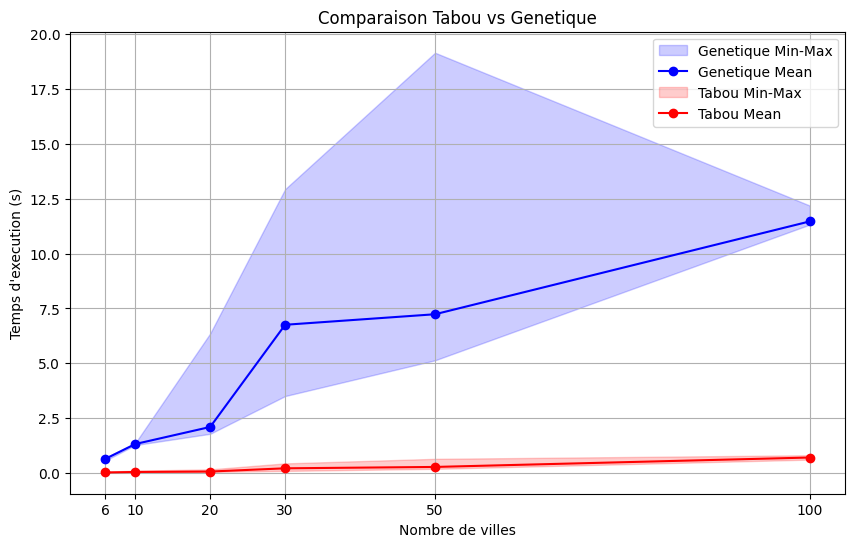

In [ ]:
algo_genetics = np.array([
    [ 0.566298,  0.643190,  0.695618],
    [ 1.274233,  1.320600,  1.362225],
    [ 1.787546,  2.099370,  6.363005],
    [ 3.508196,  6.757405, 12.941149],
    [ 5.138428,  7.237112, 19.158086],
    [11.324173, 11.469573, 12.191089],

])

algo_taboo= np.array([
    [0.013363, 0.024080, 0.067193],
    [0.038586, 0.047689, 0.105745],
    [0.052102, 0.067106, 0.166832],
    [0.096298, 0.214299, 0.438339],
    [0.190305, 0.276818, 0.646442],
    [0.610733, 0.706505, 0.808957],


])

x = [6, 10, 20, 30, 50, 100]

offset = 0

plt.figure(figsize=(10,6))

plt.fill_between(np.array(x) - offset, algo_genetics[:,0], algo_genetics[:,2], color='blue', alpha=0.2, label='Genetique Min-Max')
plt.plot(np.array(x) - offset, algo_genetics[:,1], 'o-', color='blue', label='Genetique Mean')

plt.fill_between(np.array(x) + offset, algo_taboo[:,0], algo_taboo[:,2], color='red', alpha=0.2, label='Tabou Min-Max')
plt.plot(np.array(x) + offset, algo_taboo[:,1], 'o-', color='red', label='Tabou Mean')

plt.xlabel("Nombre de villes")
plt.ylabel("Temps d'execution (s)")
plt.title("Comparaison Tabou vs Genetique")
plt.xticks(x)
plt.grid(True)
plt.legend()
plt.show()

> **Analyse :** En extrapolant l'observation du temps d'exécution (similaire à la section 2.B). Encore une fois, le temps d'exécution de l'algorithme **Génétique augmente considérablement** en fonction du nombre de villes/clients, tandis que le temps d'exécution de l'algorithme **Tabou reste très faible**.

### 5. Comparaison à Très Grande Échelle (1000 villes / > 2000 clients)
Pour évaluer la montée en charge et la robustesse des algorithmes sur des instances de 1000 villes (plus de 2000 clients), une comparaison finale a été effectuée.

#### A. Qualité de la Solution (Distance moyenne totale)

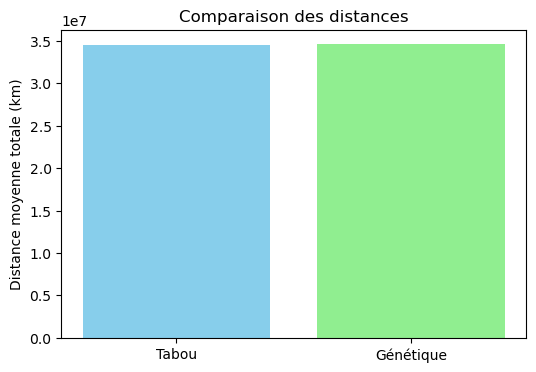

Gain de performance moyen Tabou vs Génétique : 0.21%


In [16]:

distances_taboo = np.mean([
    34353149, 34397849, 34669701, 34580713, 34466791,
    34419629, 34658246, 34370287, 34516329, 34371481,
    34616977, 34281468, 34519399, 34966849, 34548308,
    34460795, 34531895, 34559454, 34309194, 34452340
])

distances_genetic = np.mean([
    34303429, 34594176, 34447892, 34628955, 34945625,
    34538822, 34727005, 34252901, 34802361, 34761407,
    34297510, 34547504, 34705110, 34836340, 34518714,
    34639327, 34386139, 34333431, 34846089, 34402026
])

plt.figure(figsize=(6,4))
plt.bar(["Tabou","Génétique"], [distances_taboo, distances_genetic], color=["skyblue","lightgreen"])
plt.ylabel("Distance moyenne totale (km)")
plt.title("Comparaison des distances")
plt.show()

gain_percent = ((distances_genetic - distances_taboo) / distances_genetic) * 100
print(f"Gain de performance moyen Tabou vs Génétique : {gain_percent:.2f}%")


Analyse : À très grande échelle, la qualité des solutions trouvées est pratiquement équivalente. La différence est minime ($\mathbf{0,21\%}$) et montre que les deux métaheuristiques maintiennent une excellente capacité à atteindre des optima locaux de haute qualité. L'Algorithme Génétique conserve un très léger avantage en moyenne.

#### B. Temps d'Exécution (Temps moyen d'exécution)


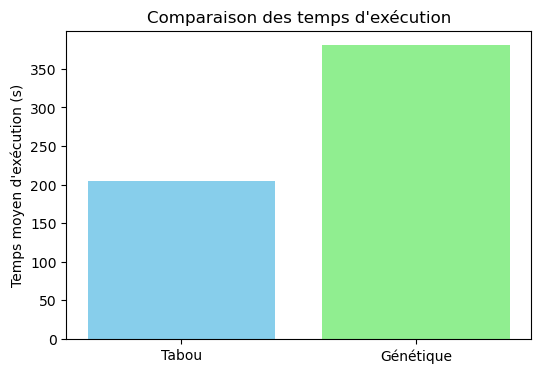

Gain de temps moyen Tabou vs Génétique : 46.18%


In [15]:
temps_taboo = np.mean([
    192.9054, 192.3097, 192.4974, 196.0068, 192.8008,
    192.4598, 194.3512, 195.0801, 196.2961, 193.7292,
    225.5304, 234.3427, 238.7574, 235.1207, 235.4504,
    214.6025, 194.1336, 192.8786, 190.8788, 194.8410
])

temps_genetic = np.mean([
    366.6802, 359.3640, 361.6687, 360.1243, 361.2971,
    364.1083, 364.0854, 363.2913, 366.9107, 370.9442,
    431.4694, 430.0859, 422.3380, 437.9503, 430.4487,
    367.6998, 359.5729, 358.8197, 369.8760, 361.6996
])

plt.figure(figsize=(6,4))
plt.bar(["Tabou","Génétique"], [temps_taboo, temps_genetic], color=["skyblue","lightgreen"])
plt.ylabel("Temps moyen d'exécution (s)")
plt.title("Comparaison des temps d'exécution")
plt.show()

gain_percent = ((temps_genetic - temps_taboo) / temps_genetic) * 100
print(f"Gain de temps moyen Tabou vs Génétique : {gain_percent:.2f}%")

Analyse : L'Algorithme Tabou est largement plus performant en temps, avec un gain de $\mathbf{46,18\%}$ sur l'Algorithme Génétique. Ceci est le facteur déterminant de l'efficacité de Tabou à grande échelle.

### 6. Conclusion Générale de l'Étude Expérimentale

L'**Algorithme Tabou** est la meilleure métaheuristique pour la résolution de ce problème de tournées de véhicules. Il offre :

1.  Une **qualité de solution équivalente** (légèrement inférieure en moyenne) à l'Algorithme Génétique.
2.  Une **stabilité supérieure** (faible variabilité des résultats).
3.  Une **vitesse d'exécution et une efficacité bien meilleures**, confirmées par un gain de temps de **46,18%** à très grande échelle.

La complexité du processus de recherche de l'Algorithme Génétique le pénalise considérablement en temps de calcul dès que l'échelle du problème augmente.